In [214]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.extensions import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
from qiskit import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram

from iminuit import Minuit
from scipy import stats
from scipy import special   
import sys 

In [209]:
from ExternalFunctions import UnbinnedLH, BinnedLH, Chi2Regression
from ExternalFunctions import nice_string_output, add_text_to_ax 
from ExternalFunctions import bin_and_fit_gauss

In [2]:
A = np.array([[1,0,0,1],
            [1,1,0,0],
            [0,1,1,1],
            [0,1,1,0]])


def make_Q(A):
    
    frob_norm = np.linalg.norm(A, 'fro') 
    m = len(A)
    n = len(A[0])
    
    B = np.zeros(((m*n),n))
    
    matrix_list = []
    for count, value in enumerate(A, start = 0):
        f_norm = np.linalg.norm(value)
        diag_vec = np.full((n), f_norm)
        diag_matrix = np.diag(diag_vec, 0)
        matrix_list.append(diag_matrix)
    
    Q = np.concatenate(matrix_list)
    Q_norm = Q/frob_norm
    return Q_norm

In [3]:
def make_P(A):
    N = len(A)
    
    vector_list = []
    for i, row in enumerate(A):
        e = np.zeros((N,))
        e[i] = 1
        column_vec = np.kron(e, row)
        norm = np.linalg.norm(row)
        norm_column_vec = column_vec/norm
        vector_list.append(norm_column_vec)
    P = np.column_stack(vector_list)
    return P
#P = make_P(A)

In [17]:
# making the Qx state for A[0]

A = np.array([[1,0,0,1],
            [1,1,0,0],
            [0,1,1,1],
            [0,1,1,0]])

Q = make_Q(A)
P = make_P(A)

Qx = Q.dot(A[2]) / np.sqrt(1) # be carefull with numpy, since smaller sqrt´s might not give exactly one. 
print(Qx) 

amplitudes = []

for i in Qx:
    amplitudes.append(i**2)

print(np.sum(amplitudes))

[0.         0.47140452 0.47140452 0.47140452 0.         0.47140452
 0.47140452 0.47140452 0.         0.57735027 0.57735027 0.57735027
 0.         0.47140452 0.47140452 0.47140452]
3.0


In [4]:
#W = np.matmul(U, V) # is this supposed to be matmul, if it isn´t, then I don´t get a unitary matrix.

def make_W(m, n, Q, P):
    U = 2 * np.matmul(P, P.T) - np.identity(m*n)
    V = 2 * np.matmul(Q, Q.T) - np.identity(m*n) 
    W = np.matmul(U, V) # is this supposed to be matmul, if it isn´t, then I don´t get a unitary matrix.
    return W

In [20]:
W = make_W(4, 4, Q, P)

<class 'qiskit.extensions.unitary.UnitaryGate'>


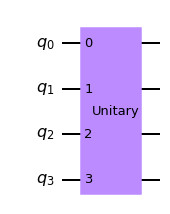

In [21]:
gate = UnitaryGate(W)

print(type(gate))
circuit = QuantumCircuit(4)
circuit.append(gate, [0, 1, 2, 3])
circuit.draw("mpl")

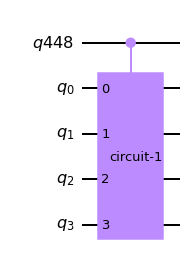

In [22]:
# making a controlled unitary 

controlled_circuit = circuit.control()
controlled_circuit.draw("mpl")

In [23]:
controlled_unitary = gate.control()

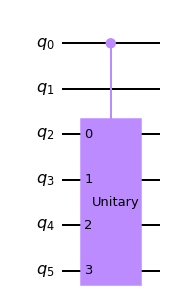

In [24]:
circuit = QuantumCircuit(6)
circuit.append(controlled_unitary, [0, 2, 3, 4, 5])
circuit.draw("mpl")

In [5]:
def binaryToDecimal(n):
    return int(n,2)

def dec_to_theta(x, n):
    return x / (2**n)

def binary_to_sigma(A, x, n):
    
    frob_norm = np.linalg.norm(A, 'fro')
    
    dec = binaryToDecimal(x)
    
    theta = dec_to_theta(dec, n)
    
    return np.cos(theta/2) * frob_norm

In [106]:
def make_circuit_and_draw(A, selected_row, qr, cr, draw = False):
    
    arr = np.array(A)
    row_sums = (arr.sum(axis = 1))

    initialize_qubits = list(range(cr, qr))


    # making circuit

    Q = make_Q(A)
    P = make_P(A)
    Qx = Q.dot(A[selected_row]) / np.sqrt(row_sums[selected_row]) # remeber we count from 0

    ### cheking amplitude

    amplitudes = []

    for i in Qx:
        amplitudes.append(i**2)
    print("Sum of amplitudes",np.sum(amplitudes))

    ###

    W = make_W(len(A), len(A[0]), Q, P)
    
    
    ### making gate for controlled unitary
    
    gate = UnitaryGate(W)
    W_circuit = QuantumCircuit(4)
    W_circuit.append(gate, [0, 1, 2, 3])
    
    controlled_circuit = W_circuit.control()
    
    #### 
    
    
    ### creating gate the initializes the state vector. 
    
    Qx_eigenvector = Statevector(Qx)
    
    
    circuit = QuantumCircuit(qr, cr)
    
    for qubit in range(cr):
        circuit.h(qubit)
    Qx_eigenvector = Statevector(Qx)
    circuit.initialize(Qx_eigenvector, initialize_qubits)
    circuit.draw("mpl")
    
    gate = UnitaryGate(W)
    
    controlled_unitary = gate.control()

    repetitions = 1
    for counting_qubit in range(cr):
        for i in range(repetitions):
            liste = [counting_qubit]
            liste.extend(initialize_qubits)
            circuit.append(controlled_circuit, liste); 
        repetitions *= 2

    circuit.barrier()
    circuit = circuit.compose(QFT(cr, inverse=True), list(range(cr)))
    circuit.barrier()

    for n in range(cr):
        circuit.measure(n,n)
    
    if draw:
        circuit.draw("mpl")
    
    return circuit

In [27]:
def run_circuit(circuit, shots):
    simulator = Aer.get_backend('aer_simulator')
    
    compiled_circuit = transpile(circuit, simulator)
    
    job = simulator.run(compiled_circuit, shots = shots)
    
    result = job.result()
    
    counts = result.get_counts(circuit)
    
    highest_value = max(counts, key=counts.get)
    
    return counts, highest_value

In [26]:
circuit = make_circuit_and_draw(A, 2, 7, 3, draw = True)

Sum of amplitudes 1.0000000000000002


In [1]:
counts, high_value = run_circuit(circuit, 256)

NameError: name 'run_circuit' is not defined

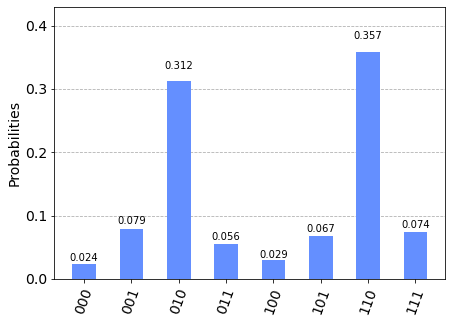

In [30]:
plot_histogram(counts)

In [177]:
counts, high_value = run_circuit_2(circuit, 512)

In [181]:
binary_to_sigma(A, high_value, 3)

3.0

In [185]:
circuit2 = make_circuit_and_draw(A, 2, 8, 4, draw = True)

Sum of amplitudes 0.9999999999999999


In [186]:
counts2, high_value2 = run_circuit_2(circuit2, 512)

In [187]:
binary_to_sigma(A, high_value2, 4)

2.676401098100983

In [188]:
circuit3 = make_circuit_and_draw(A, 2, 9, 5, draw = True)

Sum of amplitudes 0.9999999999999999


In [189]:
counts3, high_value3 = run_circuit_2(circuit3, 512)

In [190]:
binary_to_sigma(A, high_value3, 5)

2.676401098100983

In [192]:
print(high_value2, high_value3)

1111 11110


In [194]:
circuit4 = make_circuit_and_draw(A, 2, 10, 6, draw = True)

Sum of amplitudes 0.9999999999999999


In [195]:
counts4, high_value4 = run_circuit_2(circuit4, 512)

In [196]:
binary_to_sigma(A, high_value4, 6)

2.832305020671013

In [201]:
circuit5 = make_circuit_and_draw(A, 2, 11, 7, draw = True)

Sum of amplitudes 0.9999999999999999


In [202]:
counts5, high_value5 = run_circuit_2(circuit5, 512)

In [203]:
binary_to_sigma(A, high_value5, 7)

2.671086495339332

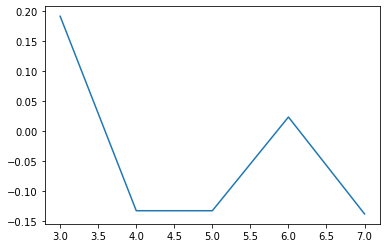

In [205]:
number_of_qubits = np.array([3, 4, 5, 6, 7])

sigma_values = np.array([3.0, 2.676401098100983, 2.676401098100983, 2.832305020671013, 2.671086495339332])

plt.plot(number_of_qubits, sigma_values - 2.80921180)

In [8]:
def decimal_to_binary(decimal):
    # Split the decimal number into integer and fractional parts
    integer_part = int(decimal)
    fractional_part = decimal - integer_part

    # Convert the integer part to binary
    binary_integer = bin(integer_part)[2:]  # Remove the '0b' prefix from the binary string

    # Convert the fractional part to binary
    binary_fractional = ''
    while fractional_part != 0.0:
        fractional_part *= 2
        bit = int(fractional_part)
        binary_fractional += str(bit)
        fractional_part -= bit

    # Combine the integer and fractional parts
    binary = binary_integer
    if binary_fractional:
        binary += '.' + binary_fractional

    return binary

In [9]:
def create_random_array(rows, cols):
    array = np.zeros((rows, cols), dtype=int)
    for i in range(rows):
        num_ones = np.random.randint(1, cols + 1)  
        col_indices = np.random.choice(cols, num_ones, replace=False)
        array[i, col_indices] = 1
    return array

In [18]:
def trials(n, qr, cr, shots):
    """n : number of trials """
    sigma_liste = []
    A_liste = []
    svd_liste = []
    counts_liste = []
    for i in range(n):
        print(i)
        A = create_random_array(4,4)
        
        A_liste.append(A)
        svd = np.linalg.svd(A)
        svd_liste.append(svd[1][0])

        circuit = make_circuit_and_draw(A, 2, qr, cr, draw = False)
        counts, high_value = run_circuit(circuit, shots)
        counts_liste.append(counts)
        
        sigma = binary_to_sigma(A, high_value, cr)

        sigma_liste.append(sigma)
        
        
    return A_liste, svd_liste, sigma_liste, counts_liste

In [19]:
def compare_sigma(sigma_liste, svd_liste):
    compared_sigma = []
    for i in range(len(sigma_liste)):
        compared_sigma.append(sigma_liste[i]/svd_liste[i])
    return compared_sigma

In [20]:
def trials_arr(n, qr, cr):
    """n : number of trials """
    sigma_arr = np.array([])
    A_arr = np.array([])
    svd_arr = np.array([])
    counts_arr = np.array([])
    for i in range(n):
        print(i)
        A = create_random_array(4,4)
        
        A_arr = np.append(A_arr, A)
        svd = np.linalg.svd(A)
        svd_arr = np.append(svd_arr, svd[1][0])

        circuit = make_circuit_and_draw(A, 2, qr, cr, draw = False)
        counts, high_value = run_circuit(circuit, shots = 256)
        counts_arr = np.append(counts_arr, counts)
        
        sigma = binary_to_sigma(A, high_value, cr)

        sigma_arr = np.append(sigma_arr, sigma)
        
        
    return A_arr, svd_arr, sigma_arr, counts_arr

In [52]:
A, svd, sigma, counts = trials(100, 9, 5, shots = 512)

0
Sum of amplitudes 0.9999999999999998
1
Sum of amplitudes 0.9999999999999999
2
Sum of amplitudes 0.9999999999999998
3
Sum of amplitudes 1.0000000000000002
4
Sum of amplitudes 1.0
5
Sum of amplitudes 1.0
6
Sum of amplitudes 0.9999999999999998
7
Sum of amplitudes 0.9999999999999998
8
Sum of amplitudes 0.9999999999999998
9
Sum of amplitudes 1.0
10
Sum of amplitudes 1.0000000000000002
11
Sum of amplitudes 0.9999999999999998
12
Sum of amplitudes 0.9999999999999999
13
Sum of amplitudes 0.9999999999999997
14
Sum of amplitudes 1.0
15
Sum of amplitudes 0.9999999999999999
16
Sum of amplitudes 1.0
17
Sum of amplitudes 1.0
18
Sum of amplitudes 1.0
19
Sum of amplitudes 0.9999999999999999
20
Sum of amplitudes 0.9999999999999998
21
Sum of amplitudes 1.0
22
Sum of amplitudes 1.0
23
Sum of amplitudes 0.9999999999999998
24
Sum of amplitudes 0.9999999999999998
25
Sum of amplitudes 1.0
26
Sum of amplitudes 1.0
27
Sum of amplitudes 1.0
28
Sum of amplitudes 1.0
29
Sum of amplitudes 1.0
30
Sum of amplitudes

In [63]:
sigma_difference_list2 = compare_sigma(sigma, svd)

In [64]:
hist_1 = np.histogram(sigma_difference_list2, bins = 20)

(array([11, 12, 19, 25, 16, 12,  2,  2,  0,  1], dtype=int64), array([0.934561  , 0.97750596, 1.02045091, 1.06339587, 1.10634083,
       1.14928578, 1.19223074, 1.23517569, 1.27812065, 1.3210656 ,
       1.36401056]))


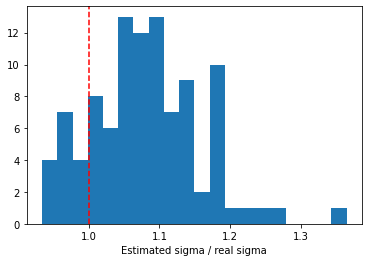

In [71]:
plt.hist(sigma_difference_list2, bins = 20)
plt.xlabel("Estimated sigma / real sigma")
plt.axvline(x = 1, color = 'r', linestyle = '--', label = "perfect approxmimation")
plt.savefig("5_qubit_100_tries.png", format = 'png')
plt.savefig("5_qubit_100_tries.eps", format = 'eps')

#markdown!!!!
plt.hist(sigma_difference_list1, bins = 20)
plt.xlabel("Estimated sigma / real sigma")
plt.axvline(x = 1, color = 'r', linestyle = '--', label = "perfect approxmimation")
plt.savefig("5_qubit_50_tries.png", format = 'png')

In [95]:
sigma_diff_list = np.append(sigma_difference_list1, sigma_difference_list2)

150


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Fit value: mu = 1.08404 +/- 0.00936
Fit value: sigma = 0.07726 +/- 0.01025
Fit value: N = 1.72858 +/- 0.19408
Chi2 value: 17.0   Ndof = 15    Prob(Chi2,Ndof) = 0.321


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


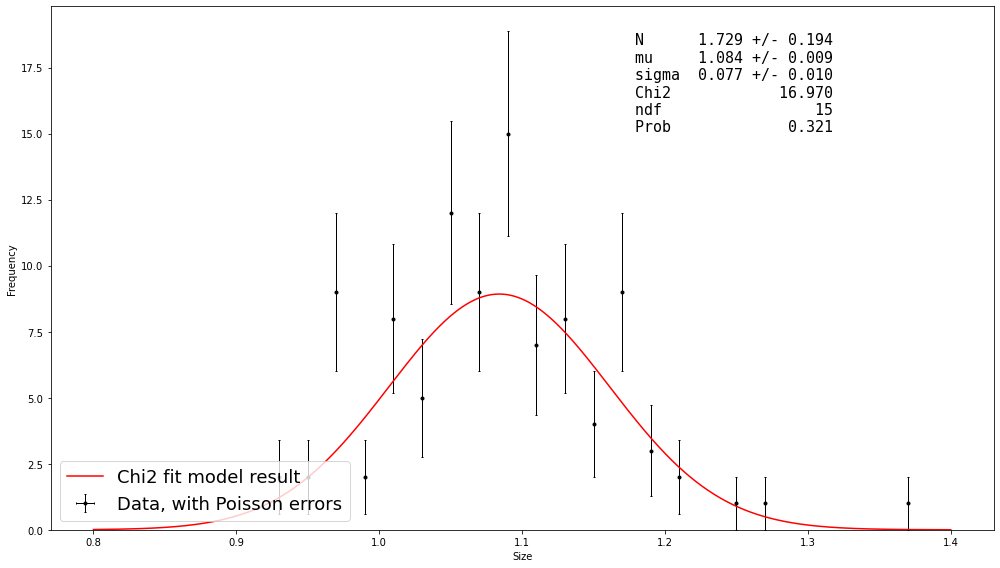

In [104]:
bin_and_fit_gauss(sigma_difference_list2, "Sigma_fit", 1.0, 0.1, 50, 30, 0.8, 1.4)

In [127]:
#print(sigma[0]/svd[0])
for i in range(50):
    print(sigma[i]/svd[i])
    plot_histogram(counts[i])

1.0762021220968567
1.09121281252451
1.054087806104975
1.2065558078457717
1.0114303436727934
1.069976520100999
1.179352503192987
1.1301654458020665
1.188541829692303
1.0598662853814018
0.9772835029076702
1.0981651185727668
1.0147552645585534
1.1039539023125917
1.1419126454397834
1.0477599326052534
1.0286127809073236
1.0814823690062234
0.9690711783054263
0.9973707432288798
1.1770256967381387
1.0441180578158757
1.1419126454397834
1.1761261317215876
1.095720708833027
1.027800369074605
1.0491981911541193
1.2182511086268395
1.044340265086108
0.9789031959365685
0.9445492945097995
1.0805609240548066
1.0611499977938033
1.0653511435482295
1.0693126580533892
1.03306811106451
1.1379781015123116
1.1321379866141401
1.119125328267372
0.9624384964231447
1.0449564949155126
1.0210494561964192
1.1273922900725322
1.008702861509752
1.17645102392893
1.120653209135368
0.9966039890149565
1.11468130137297
1.1626035096566647
0.9345610039072947


In [131]:
plot_histogram(counts[3])

print(binary_to_sigma(A[3], "00011", 5))
print(binary_to_sigma(A[3], "01111", 5))
print(svd[3])

3.1588041142638157
3.0758199714604517
2.6180339887498936


In [136]:
decimal_to_binary()

'10.10011110101110000101000111101011100001010001111011'

In [160]:
binary_to_sigma(A[3], "01011001", 5)

0.5666742419275942

In [159]:
89 / 2**5 

2.78125

In [161]:
print(svd[3])

2.6180339887498936


In [162]:
2.78125/2.6180339887498936

1.0623429687893555

In [178]:
print(binaryToDecimal("01111"))

theta = 15/(2**5)
print(theta)
dec_to_theta(15, 5)

frob_norm_3 = np.linalg.norm(A[3], 'fro')

sigma_3 = np.cos(theta/2) * frob_norm_3
print(sigma_3)

15
0.46875
3.0758199714604517


In [188]:
A3, svd3, sigma3, counts3 = trials(100, 10, 6, shots = 512)

0
Sum of amplitudes 1.0
1
Sum of amplitudes 1.0
2
Sum of amplitudes 0.9999999999999998
3
Sum of amplitudes 1.0
4
Sum of amplitudes 1.0000000000000002
5
Sum of amplitudes 1.0
6
Sum of amplitudes 0.9999999999999997
7
Sum of amplitudes 0.9999999999999998
8
Sum of amplitudes 0.9999999999999998
9
Sum of amplitudes 1.0
10
Sum of amplitudes 0.9999999999999997
11
Sum of amplitudes 0.9999999999999997
12
Sum of amplitudes 1.0
13
Sum of amplitudes 1.0
14
Sum of amplitudes 1.0
15
Sum of amplitudes 0.9999999999999997
16
Sum of amplitudes 0.9999999999999999
17
Sum of amplitudes 1.0
18
Sum of amplitudes 0.9999999999999998
19
Sum of amplitudes 0.9999999999999998
20
Sum of amplitudes 0.9999999999999998
21
Sum of amplitudes 0.9999999999999998
22
Sum of amplitudes 0.9999999999999999
23
Sum of amplitudes 1.0
24
Sum of amplitudes 1.0
25
Sum of amplitudes 0.9999999999999999
26
Sum of amplitudes 1.0
27
Sum of amplitudes 1.0
28
Sum of amplitudes 1.0
29
Sum of amplitudes 0.9999999999999998
30
Sum of amplitudes

(array([2., 1., 2., 9., 7., 3., 0., 3., 2., 1.]),
 array([0.94345447, 0.98435526, 1.02525605, 1.06615683, 1.10705762,
        1.1479584 , 1.18885919, 1.22975997, 1.27066076, 1.31156154,
        1.35246233]),
 <a list of 10 Patch objects>)

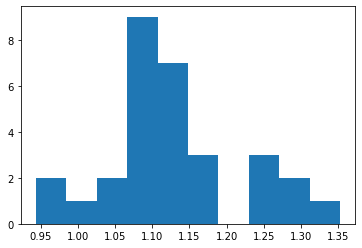

In [185]:
prøve = compare_sigma(sigma2, svd2)

plt.hist(prøve, bins = 10)

In [216]:
Comparison_6_qubits = compare_sigma(sigma3, svd3)

(array([ 3.,  7.,  7., 16., 20., 10.,  9., 10.,  6.,  3.,  4.,  0.,  1.,
         1.,  3.]),
 array([0.93969322, 0.96533509, 0.99097696, 1.01661883, 1.0422607 ,
        1.06790257, 1.09354444, 1.11918631, 1.14482818, 1.17047005,
        1.19611192, 1.22175379, 1.24739566, 1.27303753, 1.29867939,
        1.32432126]),
 <a list of 15 Patch objects>)

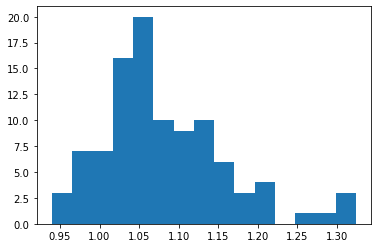

In [217]:
plt.hist(Comparison_6_qubits, bins = 15)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Fit value: mu = 1.07299 +/- 0.00940
Fit value: sigma = 0.07445 +/- 0.00854
Fit value: N = 1.46634 +/- 0.16759
Chi2 value: 22.1   Ndof = 18    Prob(Chi2,Ndof) = 0.227


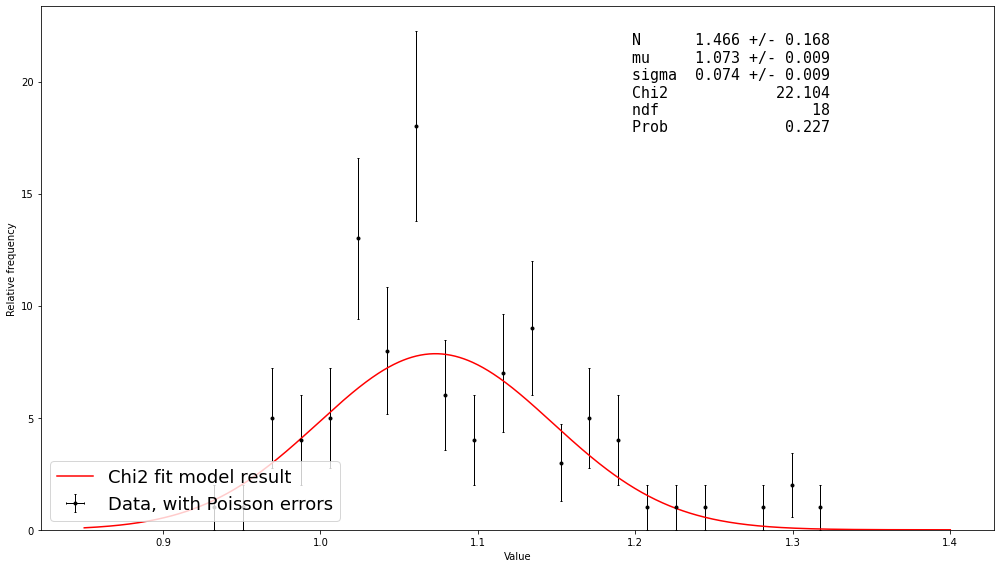

In [218]:
bin_and_fit_gauss(Comparison_6_qubits, "Sigma_fit_6_qubits", 1.0, 0.1, 50, 30, 0.85, 1.4)

In [198]:
A4, svd4, sigma4, counts4 = trials(100, 7, 3, shots = 512)

0
Sum of amplitudes 1.0
1
Sum of amplitudes 1.0
2
Sum of amplitudes 1.0
3
Sum of amplitudes 0.9999999999999998
4
Sum of amplitudes 1.0
5
Sum of amplitudes 0.9999999999999998
6
Sum of amplitudes 1.0
7
Sum of amplitudes 0.9999999999999998
8
Sum of amplitudes 1.0
9
Sum of amplitudes 0.9999999999999999
10
Sum of amplitudes 1.0000000000000002
11
Sum of amplitudes 0.9999999999999998
12
Sum of amplitudes 1.0000000000000002
13
Sum of amplitudes 1.0
14
Sum of amplitudes 0.9999999999999999
15
Sum of amplitudes 1.0000000000000002
16
Sum of amplitudes 1.0000000000000002
17
Sum of amplitudes 1.0
18
Sum of amplitudes 0.9999999999999998
19
Sum of amplitudes 0.9999999999999999
20
Sum of amplitudes 0.9999999999999998
21
Sum of amplitudes 1.0000000000000004
22
Sum of amplitudes 1.0
23
Sum of amplitudes 0.9999999999999998
24
Sum of amplitudes 0.9999999999999999
25
Sum of amplitudes 0.9999999999999998
26
Sum of amplitudes 0.9999999999999999
27
Sum of amplitudes 0.9999999999999999
28
Sum of amplitudes 1.0


1.1034396839245761


(array([ 2.,  3.,  7., 11., 15., 24., 17.,  6.,  5.,  4.,  0.,  2.,  1.,
         2.,  1.]),
 array([0.93251128, 0.96229504, 0.99207881, 1.02186257, 1.05164633,
        1.0814301 , 1.11121386, 1.14099763, 1.17078139, 1.20056515,
        1.23034892, 1.26013268, 1.28991645, 1.31970021, 1.34948397,
        1.37926774]),
 <a list of 15 Patch objects>)

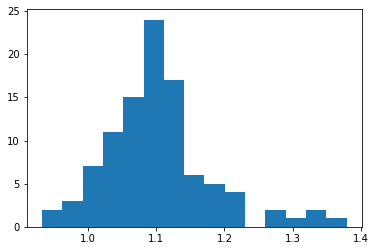

In [201]:
sigma_diff4 = compare_sigma(sigma4, svd4)

print(np.mean(sigma_diff4))
plt.hist(sigma_diff4, bins = 15)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Fit value: mu = 1.08587 +/- 0.00000
Fit value: sigma = 0.05311 +/- 0.00000
Fit value: N = 1.68089 +/- 0.00000
Chi2 value: 16.4   Ndof = 18    Prob(Chi2,Ndof) = 0.561


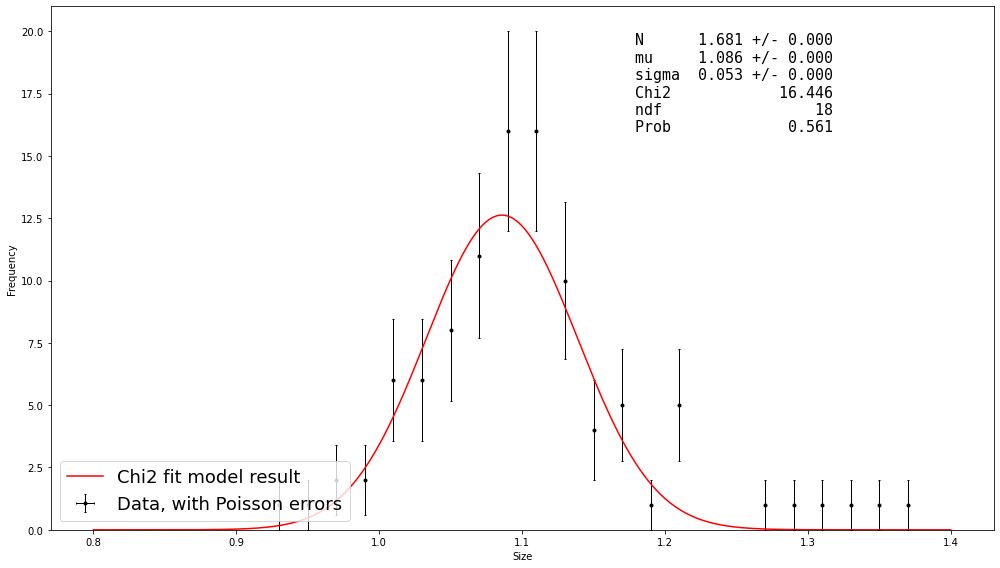

In [203]:
bin_and_fit_gauss(sigma_diff4, "Sigma_fit_3_qubits", 1.0, 0.1, 50, 30, 0.8, 1.4)

In [219]:
def bin_and_fit_gauss(data, picname, mu_value, sig_value, N_value, Nbins, xmin, xmax):
    """Fits a gaussian to binned data"""

    counts, bin_edges = np.histogram(data, bins = Nbins, range = (xmin, xmax))


    x = (bin_edges[1:][counts>0] + bin_edges[:-1][counts>0])/2
    y = counts[counts>0]
    sy = np.sqrt(counts[counts>0])   
        
    def gauss_pdf(x, mu, sigma, N):
        return N * (1 / np.sqrt(2 * np.pi) / sigma * np.exp(-0.5 * (x - mu)**2 / sigma**2))
    
    Minuit.print_level = 1    # Print result of fits (generally - can also be moved down to each fit instance)

    def chi2_owncalc(mu, sigma, N) :
        y_fit = gauss_pdf(x, mu, sigma, N)
        chi2 = np.sum(((y - y_fit) / sy)**2)
        return chi2

    minuit_chi2 = Minuit(chi2_owncalc, mu = mu_value, sigma = sig_value, N = N_value)
    minuit_chi2.errordef = 1.0     
    minuit_chi2.migrad()  
    
    fit_mu, fit_sigma, fit_N = minuit_chi2.values[:]
    
    for name in minuit_chi2.parameters :
        value, error = minuit_chi2.values[name], minuit_chi2.errors[name]
        print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")
    
    
    chi2_value = minuit_chi2.fval 
    
    N_NotEmptyBin = np.sum(y > 0)
    Ndof_value = N_NotEmptyBin - minuit_chi2.nfit
    
    Prob_value = stats.chi2.sf(chi2_value, Ndof_value) 
    print(f"Chi2 value: {chi2_value:.1f}   Ndof = {Ndof_value:.0f}    Prob(Chi2,Ndof) = {Prob_value:5.3f}")
    
    ##########################################################################################
    
    fig, ax = plt.subplots(figsize=(14, 8))  
    ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)


    ax.set(xlabel="Value", 
           ylabel="Relative frequency",  
           #title="Distribution of Gaussian and exponential numbers", 
           ylim=[0.0,None]) # 


    x_axis = np.linspace(xmin, xmax, 1000)
    ax.plot(x_axis, gauss_pdf(x_axis, *minuit_chi2.values[:]), '-r', label='Chi2 fit model result') 

    d = {'N':   [minuit_chi2.values['N'], minuit_chi2.errors['N']],
     'mu':       [minuit_chi2.values['mu'], minuit_chi2.errors['mu']],
     'sigma':       [minuit_chi2.values['sigma'], minuit_chi2.errors['sigma']],
     'Chi2':     chi2_value,
     'ndf':      Ndof_value,
     'Prob':     Prob_value,
        }

    text = nice_string_output(d, extra_spacing=2, decimals=3)
    add_text_to_ax(0.62, 0.95, text, ax, fontsize=15)
   
    ax.legend(loc='lower left', fontsize=18); # could also be # loc = 'upper right' e.g.
    fig.tight_layout()
    
    #fig.savefig(f"{picname}", format = "png")
    
    fig.savefig(f"{picname}.eps", format = "eps")

    

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Fit value: mu = 1.07305 +/- 0.00940
Fit value: sigma = 0.07444 +/- 0.00853
Fit value: N = 1.46661 +/- 0.16759
Chi2 value: 22.1   Ndof = 18    Prob(Chi2,Ndof) = 0.227


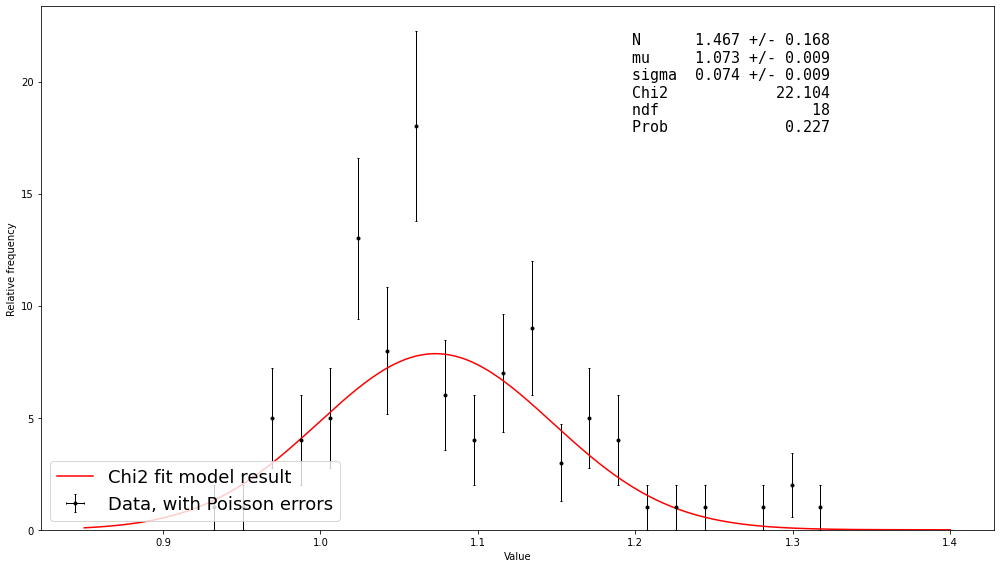

In [222]:
bin_and_fit_gauss(Comparison_6_qubits, "Sigma_fit_6_qubits", 1.0, 0.1, 1, 30, 0.85, 1.4)